In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [4]:
# Load Dataset
titanic = sns.load_dataset("titanic")

# Select Features and Target
features = ["pclass", "sex", "fare", "embarked", "age"]
target = "survived"

# -------------------------
# Handle Missing Data
# -------------------------

# Age → Median
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

# Embarked → Most Frequent
imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# -------------------------
# Encode Categorical Data
# -------------------------

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

# -------------------------
# Define X and y
# -------------------------

X = titanic[features]
y = titanic[target]

# -------------------------
# Train Test Split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [28]:
model = DecisionTreeClassifier(random_state=42,max_depth=4)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train= model.predict(X_train)

accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)

print("Training Accuracy:", accuracy_train* 100 ,"%")
print(" Testing Accuracy :", accuracy_test* 100 ,"%")

Training Accuracy: 84.75120385232745 %
 Testing Accuracy : 82.46268656716418 %


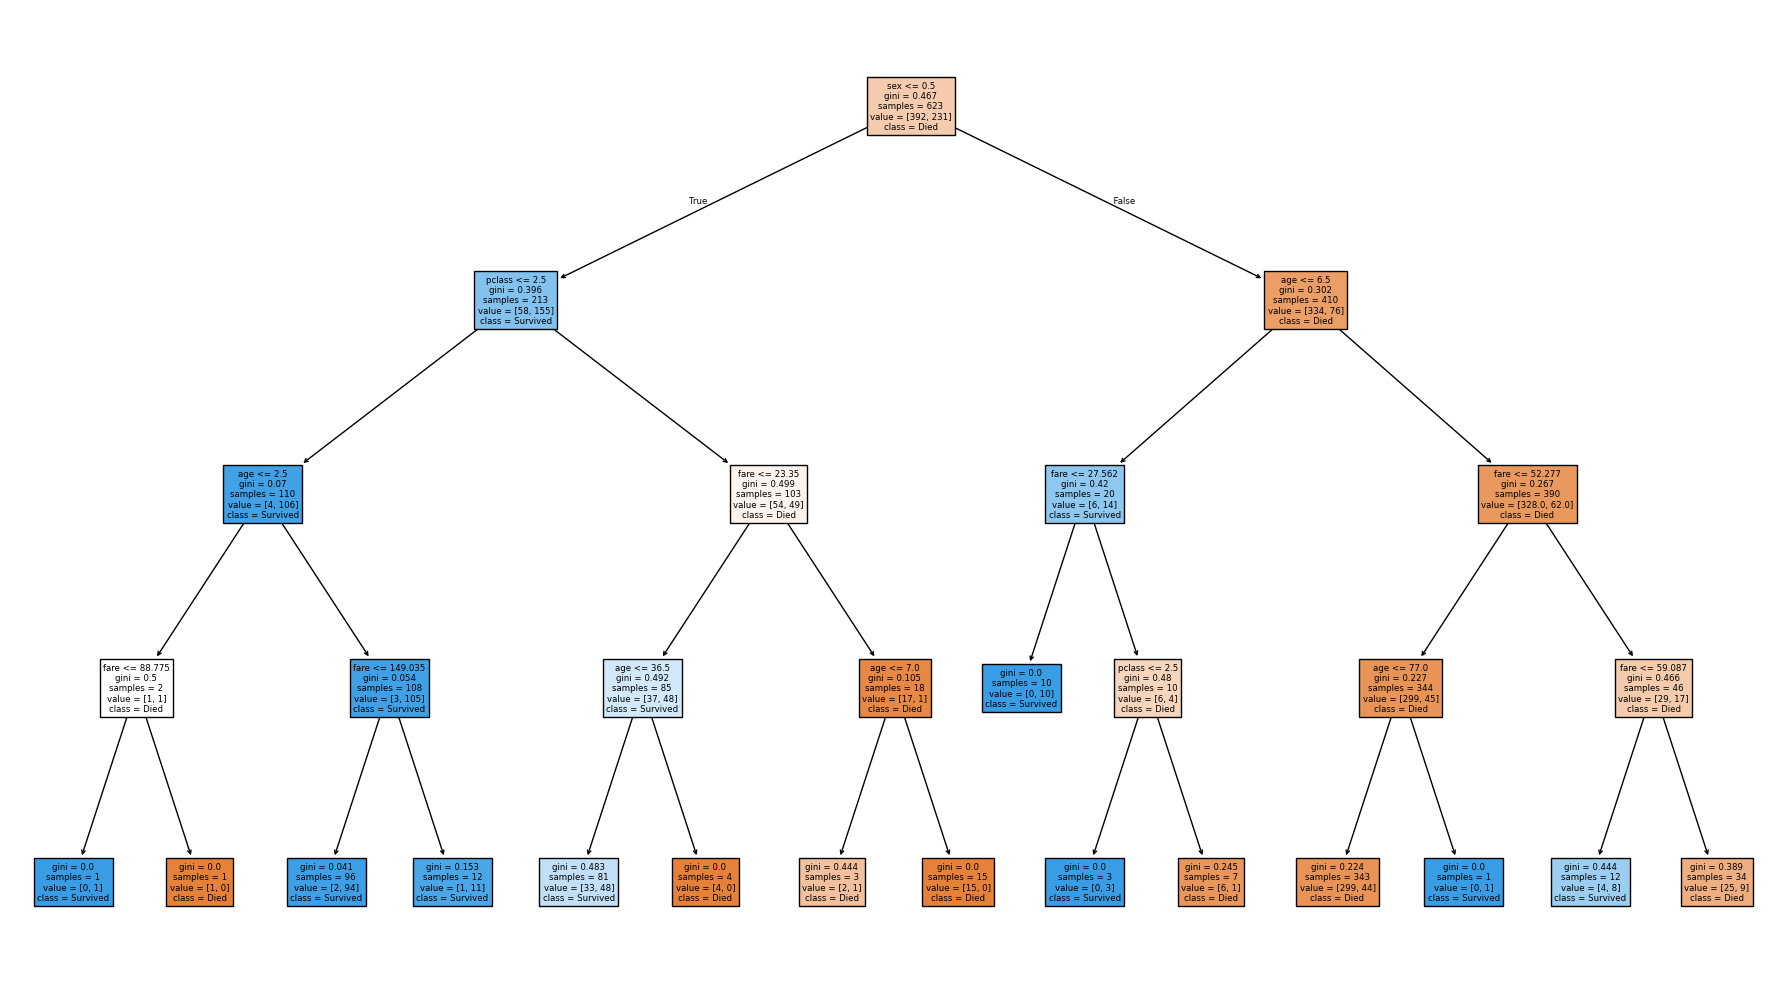

In [29]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    
)

plt.tight_layout()
plt.show()


In [30]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth=4 
)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("OOB score",rf.oob_score_ * 100," % ")
print("Testng Accacy",accuracy_score(y_test,y_pred)* 100," % ")

OOB score 82.34349919743178  % 
Testng Accacy 81.34328358208955  % 


In [34]:
# Bagging Classifier
from sklearn.ensemble import BaggingClassifier

base_model=DecisionTreeClassifier(random_state=42,max_depth=4)
bagging=BaggingClassifier(
    base_model,
    n_estimators=201,
)

bagging.fit(X_train, y_train)

y_pred_test = bagging.predict(X_test)
y_pred_train= bagging.predict(X_train)

accuracy_test = accuracy_score(y_test, y_pred_test)
print(accuracy_test)

0.8134328358208955


In [35]:
from sklearn.linear_model import LogisticRegression

base_model=LogisticRegression(max_iter=1000)
bagging=BaggingClassifier(
    base_model,
    n_estimators=201,
)

bagging.fit(X_train, y_train)

y_pred_test = bagging.predict(X_test)
y_pred_train= bagging.predict(X_train)

accuracy_test = accuracy_score(y_test, y_pred_test)
print(accuracy_test)

0.7947761194029851


In [40]:
import numpy as np
from sklearn.svm import SVR
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,accuracy_score


# Sample dataset
from sklearn.datasets import load_diabetes
data = load_diabetes()

X = data.data
y = data.target

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Base Model (SVR)
svr = SVR(kernel='rbf')

# Bagging Model
bagging_svr = BaggingRegressor(
    estimator=svr,
    n_estimators=50,        # number of SVR models
    
)

# Train
bagging_svr.fit(X_train, y_train)

# Predict
y_pred = bagging_svr.predict(X_test)

# Evaluate
print("R2 Score:", r2_score(y_test, y_pred))


R2 Score: 0.16694859307477194
